# SVM with NumPy — Mini-Batch SGD + Kernel Approximation

Two approaches:
- **Linear SVM** via vectorised mini-batch subgradient descent
- **Kernel SVM** via Random Fourier Features (RBF approximation)

**Dataset:** Breast Cancer  
**Model saved to:** `../Models/svm_numpy.npz`

## 1. Load & Prepare Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

data  = load_breast_cancer()
X_raw = data.data
y_raw = np.where(data.target == 1, 1, -1).astype(np.float64)  # {-1, +1}
class_names = list(data.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0) + 1e-8
X_train_sc = (X_train - X_mean) / X_std
X_test_sc  = (X_test  - X_mean) / X_std

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}  |  Features: {X_raw.shape[1]}")

Train: 455  |  Test: 114  |  Features: 30


---
# Part A — Linear SVM (Vectorised Mini-Batch Subgradient)

Same primal objective as the scratch version, but with:
- **Mini-batches**: sample a random subset each step → noisy but faster
- **Fully vectorised**: no Python loops inside the update
- **Pegasos step size**: $\eta_t = 1/(\lambda t)$ — theoretically motivated decay

In [2]:
class LinearSVM:
    """
    Soft-margin linear SVM via mini-batch subgradient descent.
    Primal: min (λ/2)||w||² + (1/n) Σ max(0, 1 - y_i(w·x_i + b))
    where C = 1/λ.
    """
    def __init__(self, C=1.0, lr=0.01, epochs=500,
                 batch_size=32, lr_schedule='constant'):
        self.C           = C
        self.lr          = lr
        self.epochs      = epochs
        self.batch_size  = batch_size
        self.lr_schedule = lr_schedule
        self.w  = None
        self.b  = 0.0
        self.losses = []

    def _step(self, t):
        if self.lr_schedule == 'pegasos':   # η = 1/(λt)
            lam = 1 / self.C
            return 1 / (lam * t)
        elif self.lr_schedule == 'sqrt':    # η = lr / √t
            return self.lr / np.sqrt(t)
        return self.lr

    def _loss(self, X, y):
        hinge = np.maximum(0.0, 1.0 - y * (X @ self.w + self.b))
        return 0.5 * np.dot(self.w, self.w) + self.C * hinge.mean()

    def fit(self, X, y, verbose=True):
        n, p      = X.shape
        self.w    = np.zeros(p)
        self.b    = 0.0
        self.losses = []
        t         = 0

        for epoch in range(1, self.epochs + 1):
            idx  = np.random.permutation(n)
            X_sh, y_sh = X[idx], y[idx]

            for start in range(0, n, self.batch_size):
                Xb = X_sh[start:start + self.batch_size]
                yb = y_sh[start:start + self.batch_size]
                t += 1
                eta = self._step(t)

                margins = yb * (Xb @ self.w + self.b)   # (batch,)
                mask    = margins < 1.0                  # hinge active

                # Vectorised subgradient
                dw = self.w - self.C * (yb[mask, None] * Xb[mask]).mean(axis=0) if mask.any() else self.w
                db = -self.C * yb[mask].mean() if mask.any() else 0.0

                self.w -= eta * dw
                self.b -= eta * db

            self.losses.append(self._loss(X, y))

            if verbose and (epoch % 100 == 0 or epoch == 1):
                acc = np.mean(self.predict(X) == y)
                print(f"Epoch {epoch:>4} | Loss: {self.losses[-1]:.4f} | Acc: {acc:.4f}")

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))

    @property
    def margin(self):
        return 2 / np.linalg.norm(self.w)

    @property
    def support_vectors_mask(self):
        return None   # set externally after fit

In [3]:
np.random.seed(42)
svm_linear = LinearSVM(C=1.0, lr=0.01, epochs=300, batch_size=32, lr_schedule='sqrt')
svm_linear.fit(X_train_sc, y_train)

Epoch    1 | Loss: 0.5610 | Acc: 0.9385
Epoch  100 | Loss: 0.3079 | Acc: 0.9780
Epoch  200 | Loss: 0.3254 | Acc: 0.9780
Epoch  300 | Loss: 0.3337 | Acc: 0.9780


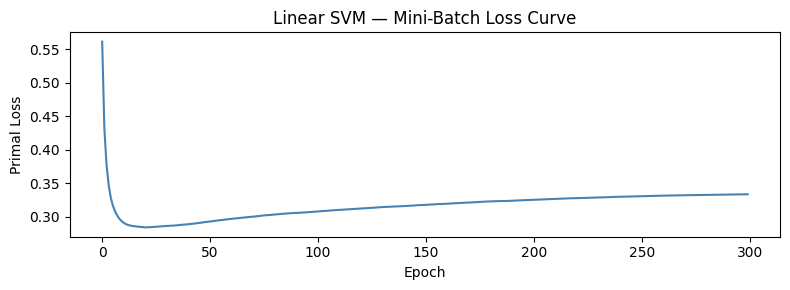

Test Accuracy: 0.9649
Margin:        2.9825


In [4]:
plt.figure(figsize=(8, 3))
plt.plot(svm_linear.losses, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Primal Loss')
plt.title('Linear SVM — Mini-Batch Loss Curve')
plt.tight_layout(); plt.show()

y_pred = svm_linear.predict(X_test_sc)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Margin:        {svm_linear.margin:.4f}")

## Pegasos vs Constant vs Sqrt LR Schedules

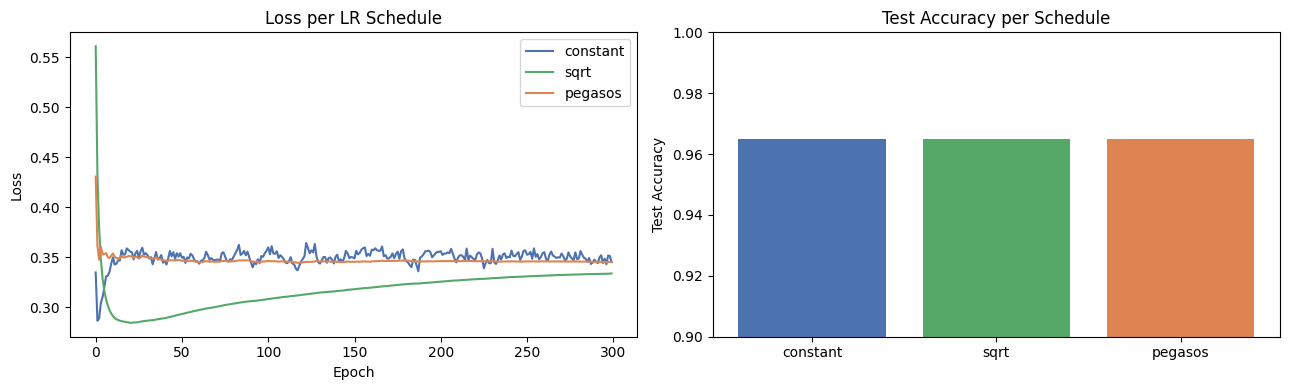

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
schedules = [('constant', 0.01), ('sqrt', 0.01), ('pegasos', None)]
colors    = ['#4C72B0', '#55A868', '#DD8452']

for (sched, lr), col in zip(schedules, colors):
    np.random.seed(42)
    lr_ = lr or 0.01
    m   = LinearSVM(C=1.0, lr=lr_, epochs=300, batch_size=32, lr_schedule=sched)
    m.fit(X_train_sc, y_train, verbose=False)
    axes[0].plot(m.losses, label=sched, color=col)
    axes[1].bar(sched, accuracy_score(y_test, m.predict(X_test_sc)), color=col)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss per LR Schedule'); axes[0].legend()
axes[1].set_ylabel('Test Accuracy'); axes[1].set_title('Test Accuracy per Schedule')
axes[1].set_ylim(0.9, 1.0)
plt.tight_layout(); plt.show()

---
# Part B — Kernel SVM via Random Fourier Features (RFF)

The kernel trick allows SVMs to learn non-linear boundaries, but requires
computing an $n \times n$ Gram matrix — $O(n^2)$ memory.

**Random Fourier Features** (Rahimi & Recht, 2007) approximate the RBF kernel
with an explicit low-dimensional feature map $\phi(x)$, so we can still train
a *linear* SVM in the mapped space:

$$k(x, z) = e^{-\gamma\|x-z\|^2} \approx \phi(x)^T\phi(z)$$

$$\phi(x) = \sqrt{\frac{2}{D}}\cos(W x + b), \quad
W_{ij} \sim \mathcal{N}(0, 2\gamma), \quad b_i \sim \text{Uniform}(0, 2\pi)$$

This gives the non-linear power of a kernel SVM without the $O(n^2)$ cost.

In [6]:
class RBFFeatureMap:
    """
    Random Fourier Features approximation of the RBF kernel.
    Fit on train, transform both train and test.
    """
    def __init__(self, n_components=100, gamma=1.0, random_state=42):
        self.n_components   = n_components
        self.gamma          = gamma
        self.random_state   = random_state

    def fit(self, X):
        rng        = np.random.default_rng(self.random_state)
        n_features = X.shape[1]
        # Sample W from N(0, 2γ) — the Fourier transform of the RBF kernel
        self.W_ = rng.normal(0, np.sqrt(2 * self.gamma), (n_features, self.n_components))
        self.b_ = rng.uniform(0, 2 * np.pi, self.n_components)
        return self

    def transform(self, X):
        Z = X @ self.W_ + self.b_                     # (n, D)
        return np.sqrt(2 / self.n_components) * np.cos(Z)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [7]:
# Fit RFF on train, transform both
D   = 200      # number of random features
rff = RBFFeatureMap(n_components=D, gamma=0.1, random_state=42)
X_train_rff = rff.fit_transform(X_train_sc)
X_test_rff  = rff.transform(X_test_sc)

print(f"Original features : {X_train_sc.shape[1]}")
print(f"RFF features      : {X_train_rff.shape[1]}")

# Train linear SVM in the RFF space
np.random.seed(42)
svm_rff = LinearSVM(C=1.0, lr=0.01, epochs=300, batch_size=32, lr_schedule='sqrt')
svm_rff.fit(X_train_rff, y_train)

y_pred_rff = svm_rff.predict(X_test_rff)
print(f"\nLinear SVM (original): {accuracy_score(y_test, svm_linear.predict(X_test_sc)):.4f}")
print(f"Kernel SVM via RFF  : {accuracy_score(y_test, y_pred_rff):.4f}")

Original features : 30
RFF features      : 200
Epoch    1 | Loss: 0.9921 | Acc: 0.6264
Epoch  100 | Loss: 0.9278 | Acc: 0.6264
Epoch  200 | Loss: 0.9043 | Acc: 0.6264
Epoch  300 | Loss: 0.8873 | Acc: 0.6264

Linear SVM (original): 0.9649
Kernel SVM via RFF  : 0.6316


## RFF Components vs Accuracy

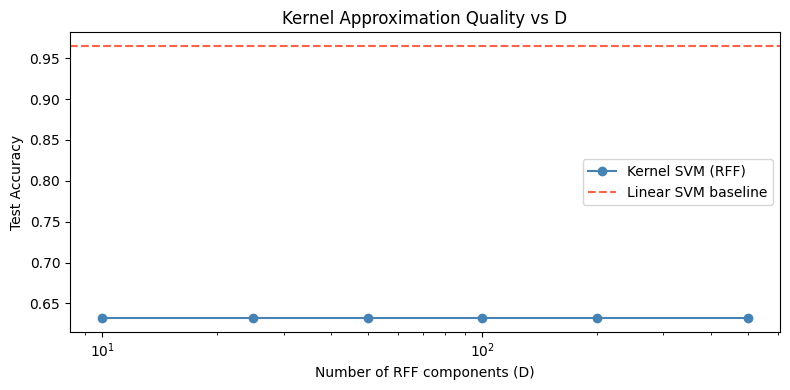

In [8]:
D_values = [10, 25, 50, 100, 200, 500]
rff_accs = []

for d in D_values:
    rff_ = RBFFeatureMap(n_components=d, gamma=0.1, random_state=42)
    Xtr_ = rff_.fit_transform(X_train_sc)
    Xte_ = rff_.transform(X_test_sc)
    np.random.seed(42)
    m = LinearSVM(C=1.0, lr=0.01, epochs=200, batch_size=32, lr_schedule='sqrt')
    m.fit(Xtr_, y_train, verbose=False)
    rff_accs.append(accuracy_score(y_test, m.predict(Xte_)))

plt.figure(figsize=(8, 4))
plt.semilogx(D_values, rff_accs, marker='o', color='steelblue', label='Kernel SVM (RFF)')
plt.axhline(accuracy_score(y_test, svm_linear.predict(X_test_sc)),
            linestyle='--', color='tomato', label='Linear SVM baseline')
plt.xlabel('Number of RFF components (D)')
plt.ylabel('Test Accuracy')
plt.title('Kernel Approximation Quality vs D')
plt.legend(); plt.tight_layout(); plt.show()

## Confusion Matrix — Both Methods

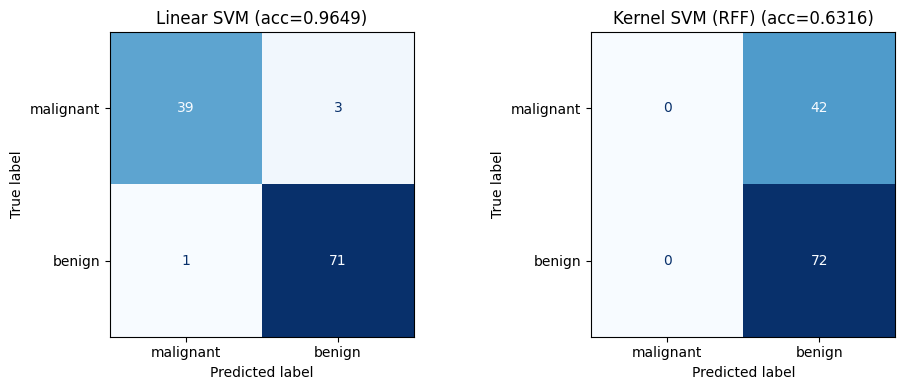

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, title in [
    (ax1, svm_linear.predict(X_test_sc), 'Linear SVM'),
    (ax2, svm_rff.predict(X_test_rff),   'Kernel SVM (RFF)')
]:
    p01 = np.where(preds == 1, 1, 0)
    t01 = np.where(y_test == 1, 1, 0)
    cm  = confusion_matrix(t01, p01)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title} (acc={accuracy_score(t01,p01):.4f})')
plt.tight_layout(); plt.show()

## Save Model to `../Models/`

In [10]:
np.savez_compressed('../Models/svm_numpy.npz',
    # Linear SVM
    w=svm_linear.w, b=np.array(svm_linear.b), C=np.array(svm_linear.C),
    x_mean=X_mean, x_std=X_std,
    # RFF kernel SVM
    w_rff=svm_rff.w, b_rff=np.array(svm_rff.b),
    rff_W=rff.W_, rff_b=rff.b_, rff_gamma=np.array(rff.gamma)
)
print(f"Saved → ../Models/svm_numpy.npz  "
      f"({os.path.getsize('../Models/svm_numpy.npz')/1024:.1f} KB)")

Saved → ../Models/svm_numpy.npz  (50.5 KB)
